In [1]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy
from kneed import KneeLocator
from typing import Tuple, Literal, Any, Optional
import scipy.stats as stats
from gensim.models import KeyedVectors
import re
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib as mpl
from cycler import cycler
from utils import *
from utils import find_elbow, _remap


In [2]:
print(sanity_check())

Version 2


In [ ]:
df = pd.read_csv('../data/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})

In [4]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', '#3EB489', '#6B8E23'])

In [5]:
# Minor preprossesing that will be useful for later
df.fillna('NaN', inplace=True)

def _remove_special_characters(text:str) -> str:
    return re.sub(r"[^a-zA-Z0-9 ]", "  ", text)

def _replace_covid(text:str) -> str:
    return re.sub('COVID', 'CORONOVIRUS', text)

df['REASON_VISIT_NAME'] = df['REASON_VISIT_NAME'].apply(_remove_special_characters).apply(_replace_covid)

In [6]:
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons.sort()
unique_reasons.shape

(868,)

In [ ]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admission'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


# Syndromic Grouping & Clustering

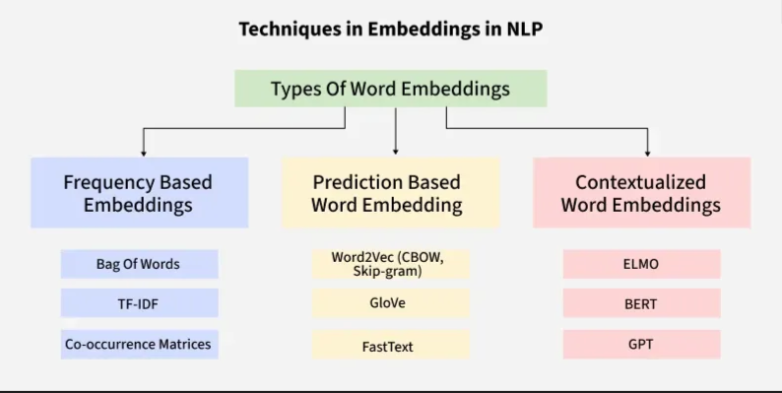

* Vectorizers used so far: TF-IDF, W2V
* Clustering algorithms used so far: K-Means, BisectingKMeans

* Note, up to discussion: should we cluster based on semantic or textual similarity? If we want semantic we need to normalize, to make the Euclidean distance equivalent to the cosine similarity (which is done a toggle is put in the basic function).

## TF-IDF

In [8]:
# vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=False)

# X = vectorizer.fit_transform(unique_reasons) # return a sparse matrix where row -> reason, column -> embedding vector entries
# vectorizer.get_feature_names_out().tolist()[:5]

## BioWordVec
https://github.com/ncbi-nlp/BioSentVec?tab=readme-ov-file#biowordvec

In [9]:
# # Sanity check: we are not missing any words from the model, which is due to preprocessing

# l=[]
# for r in unique_reasons:
#     tokens = r.lower().split()
#     check = l.extend([word for word in tokens if word not in bwv.key_to_index])

# l


## K-Means & Bisecting K-means

In [10]:
# Data for tf-idf 
e_t = vectorize(data=unique_reasons, unique_reasons=unique_reasons, vectorizer='tf_idf', normalize=True)

# Data for w2v
e_w = vectorize(data=unique_reasons, unique_reasons=unique_reasons, vectorizer='bio_word_vec', normalize=True)

### Optimization of numbers of clusters

https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d

https://medium.com/@jeffzyme/understanding-inertia-distortion-and-silhouette-scores-and-their-differences-key-metrics-for-458fe28ce2aa

Three "standard" measures for analysis of clustering algorithms:
* **Inertia:** Measures the compactness of the clusters i.e. how close the points of each cluster is to their respective centroid. 
$$\text{INERTIA} =\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert^2$$
It’s particularly useful in the Elbow Method when combined with distortion.

* **Distortion:** Lower distortion scores suggest points are tightly grouped, but too many clusters may imply overfitting. 
$$\text{Distortion Score} = \frac{1}{N}\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert$$

* **Silhouette:** High average silhouette scores across all points suggest strong clustering, with distinct separation between clusters. This score is particularly insightful for comparing different clustering approaches, as it evaluates both within-cluster tightness and inter-cluster separation. For $x\in C$
$$\text{Silhouette Score}=\frac{b-a}{\max(a,b)}$$
 where $a$ is the average distance of $x$ to every other point in its cluster and $b$ is the average from all the points to the neighboring cluster (i.e. the cluster with the closer centroid).

The overall Silhouette Score is the average of silhouette scores for all points, producing a range from −1 to 1:

*    Values close to 1 indicate well-separated clusters,
*    Values near 0 suggest overlapping clusters,
*    Negative values signal possible misclassification.

In [11]:
raw_count = reason_count.sort_index()['total_occurences_of_reason'].to_numpy()
log_count = np.log(1+raw_count)
admission_rate = (reason_count.sort_index()['percentage_of_admission']/100).to_numpy() # admission rate per unique reason
joint = log_count*admission_rate
_weight_by = {'raw_count':raw_count, 'log_count':log_count, 'admission_rate':admission_rate, 'joint':joint, None:None}


In [12]:
# Possibilities

embeddings = {'tf-idf':e_t, 'bwv':e_w}
weights = [None, 'raw_count', 'log_count', 'admission_rate', 'joint']
models = ['kmeans', 'bkmeans']

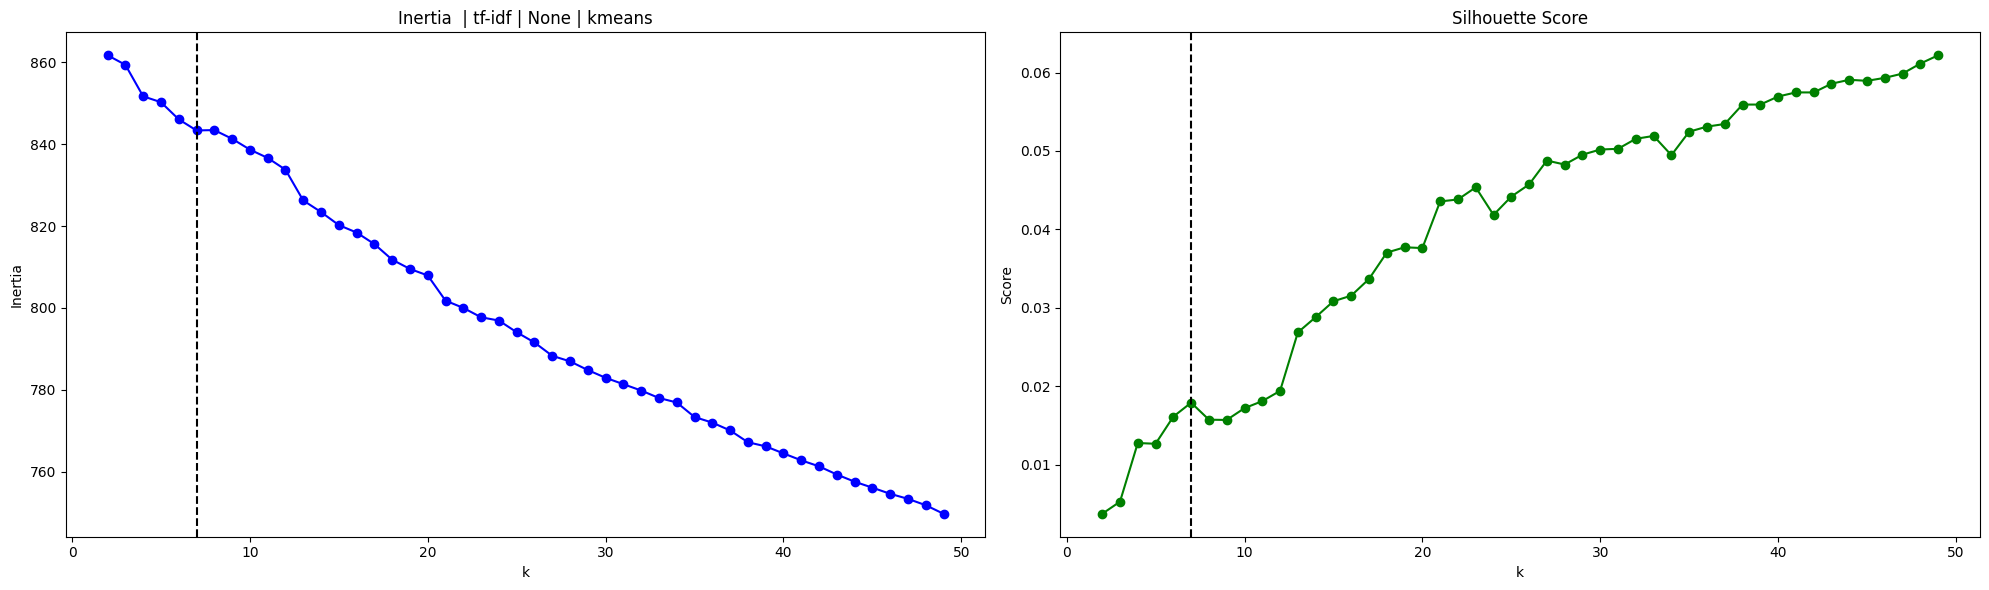

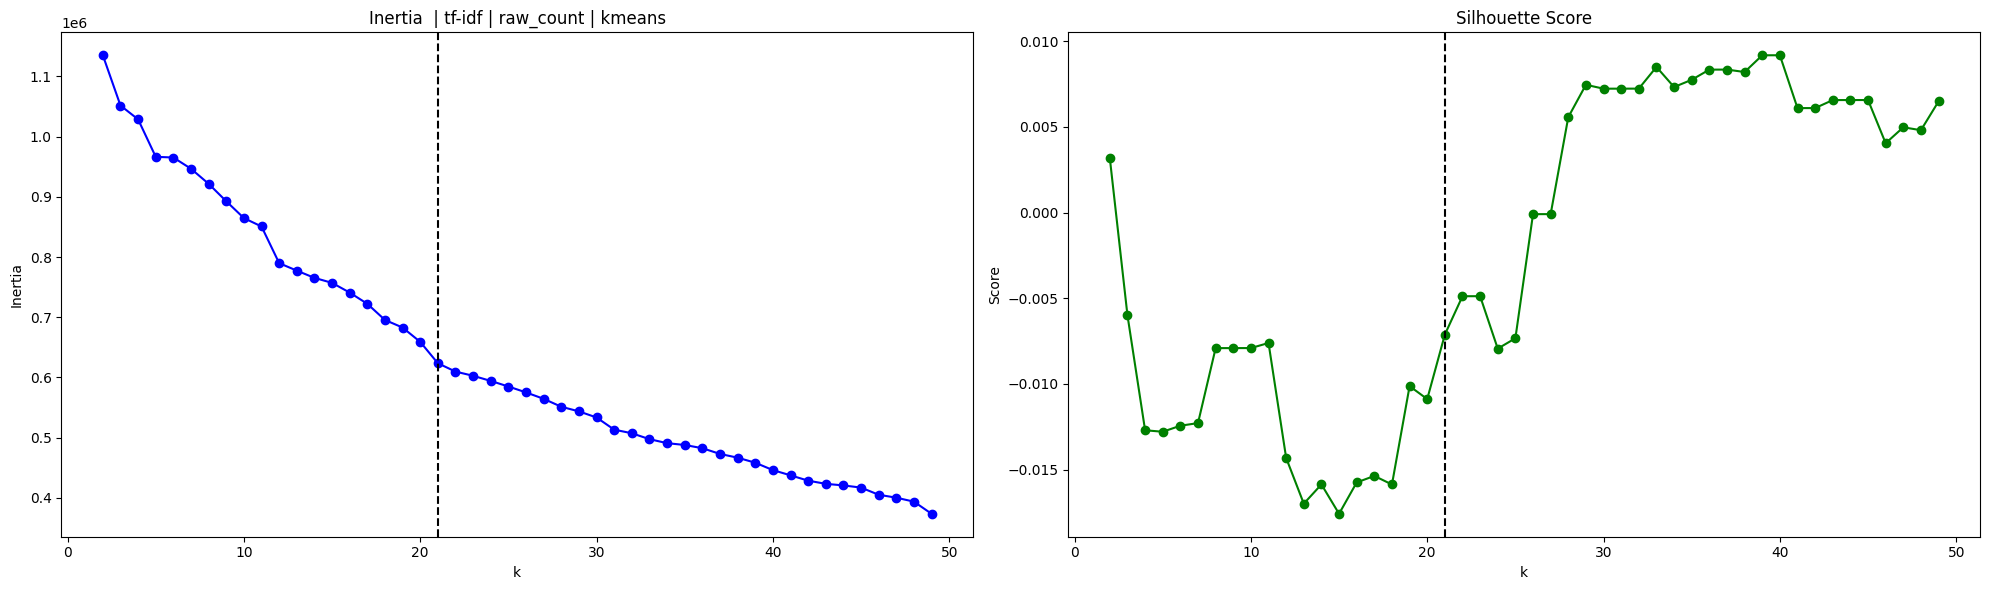

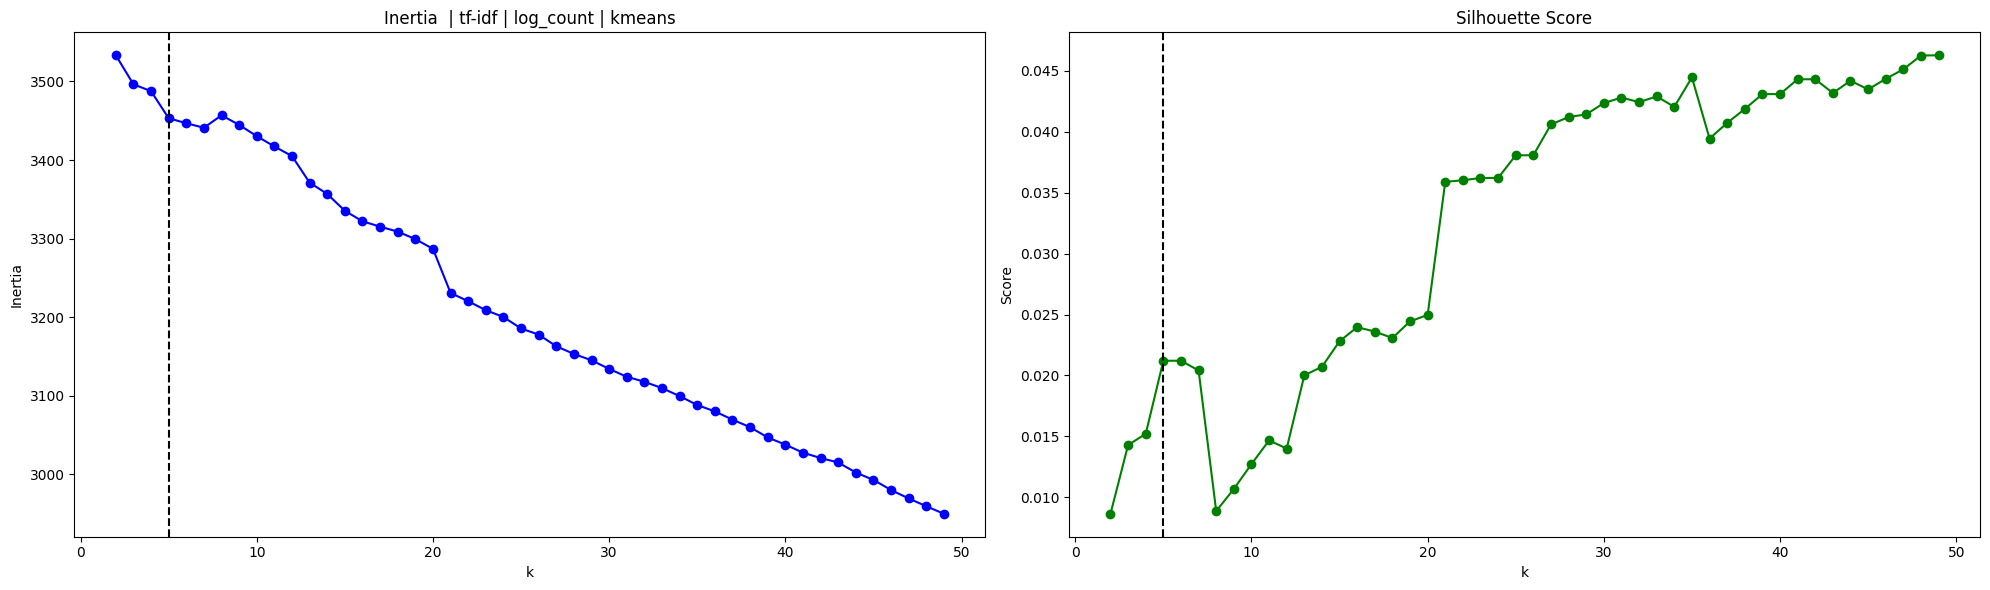

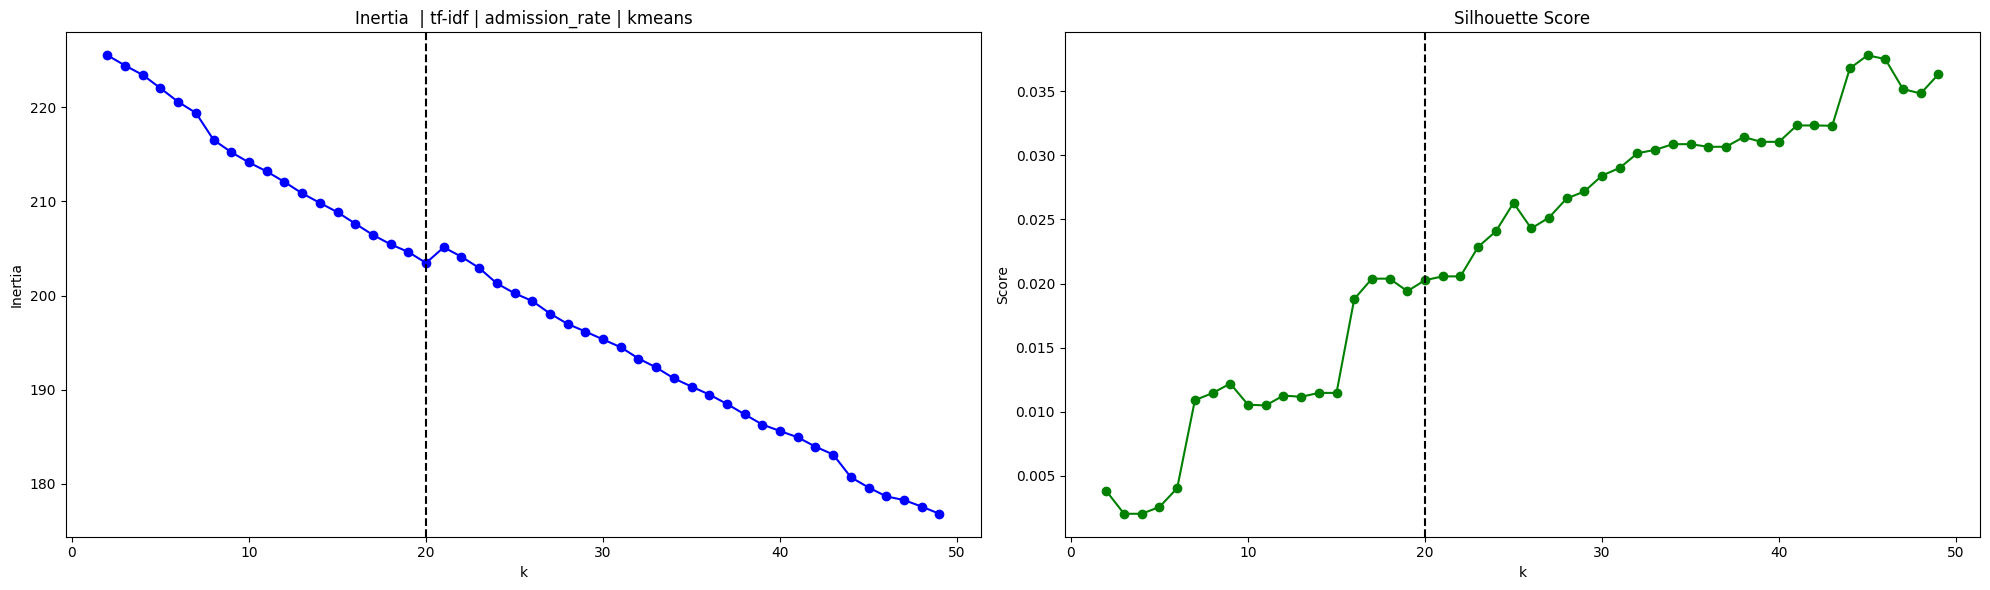

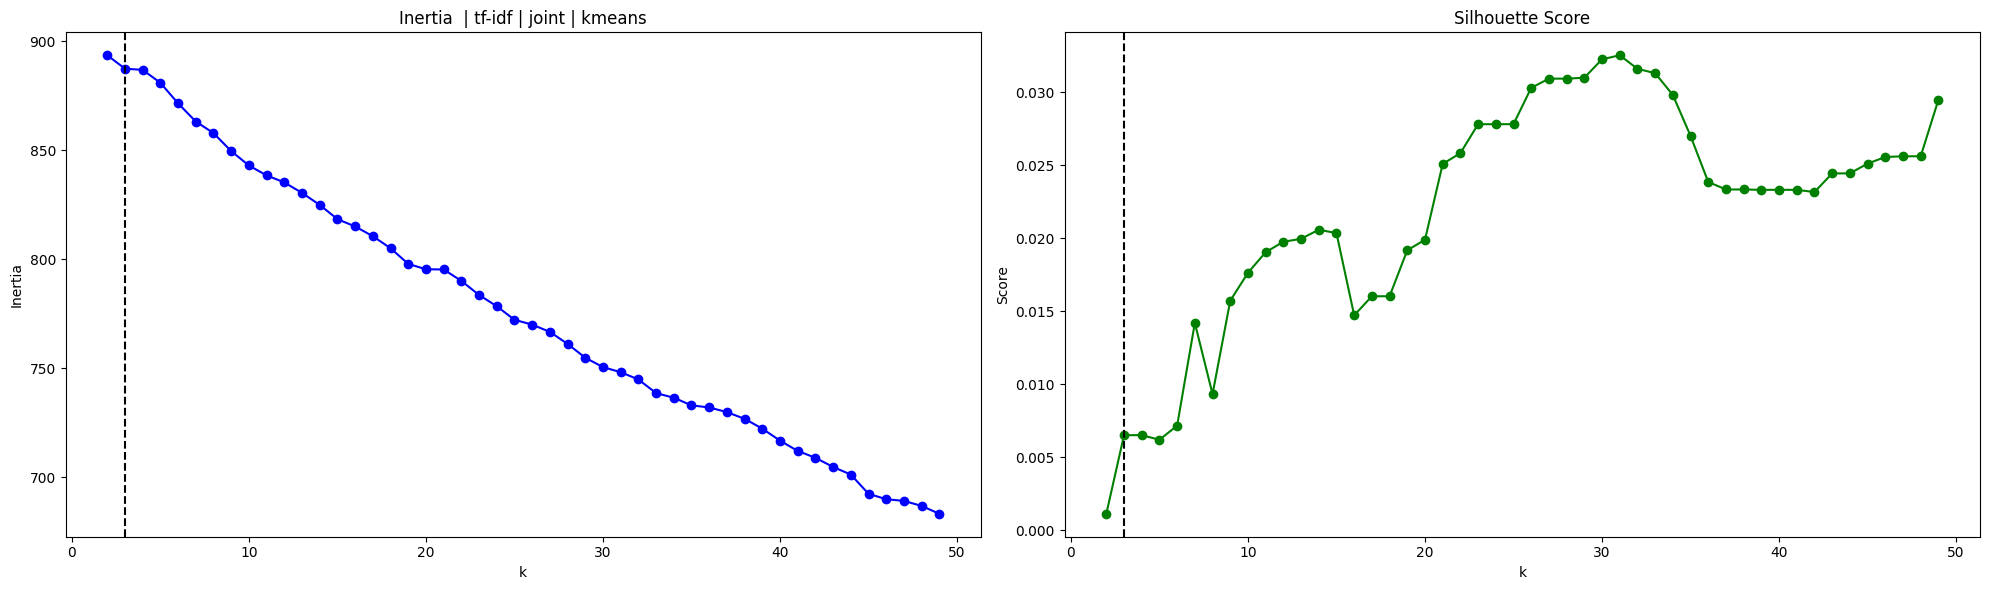

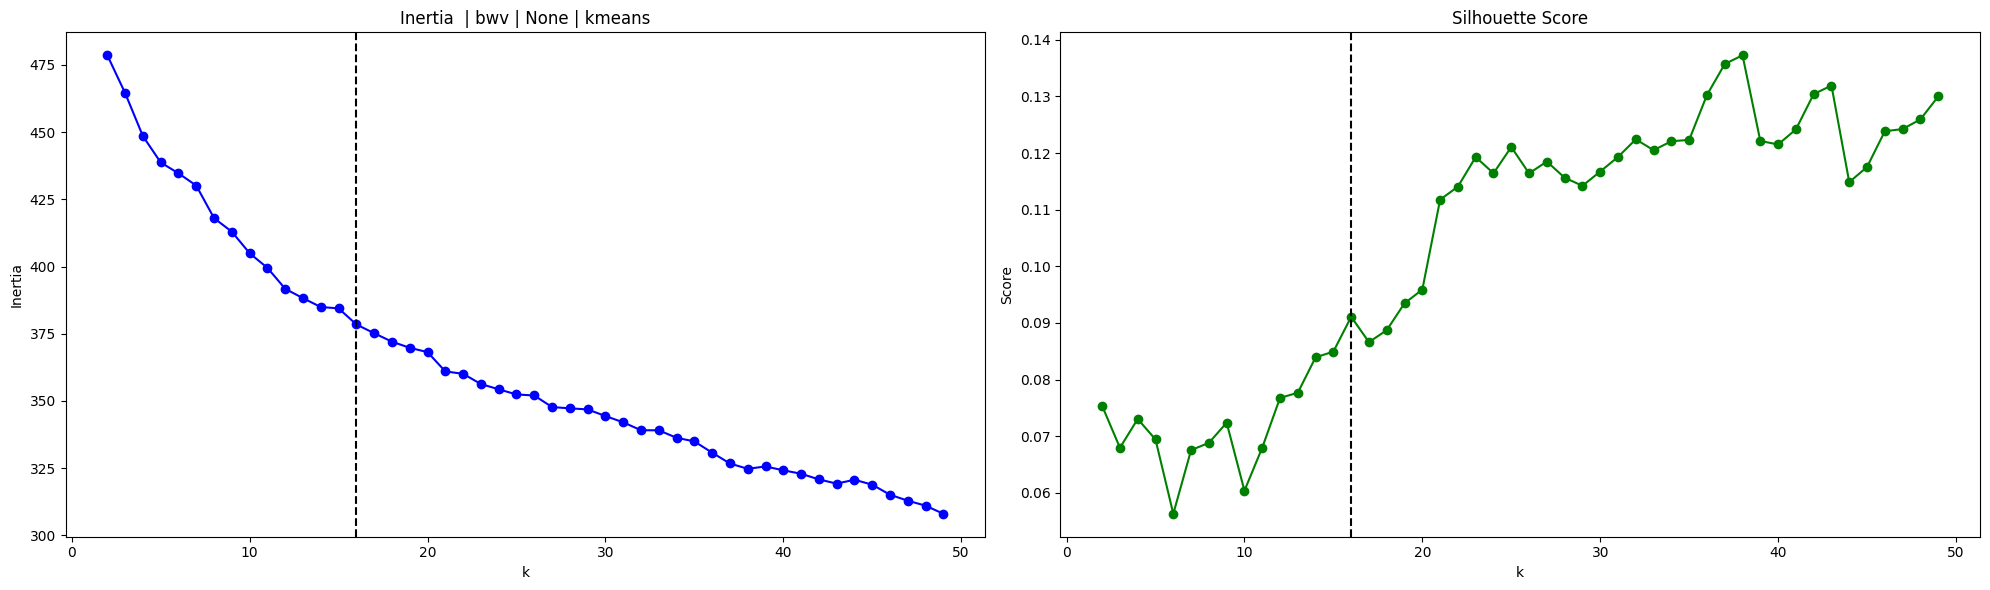

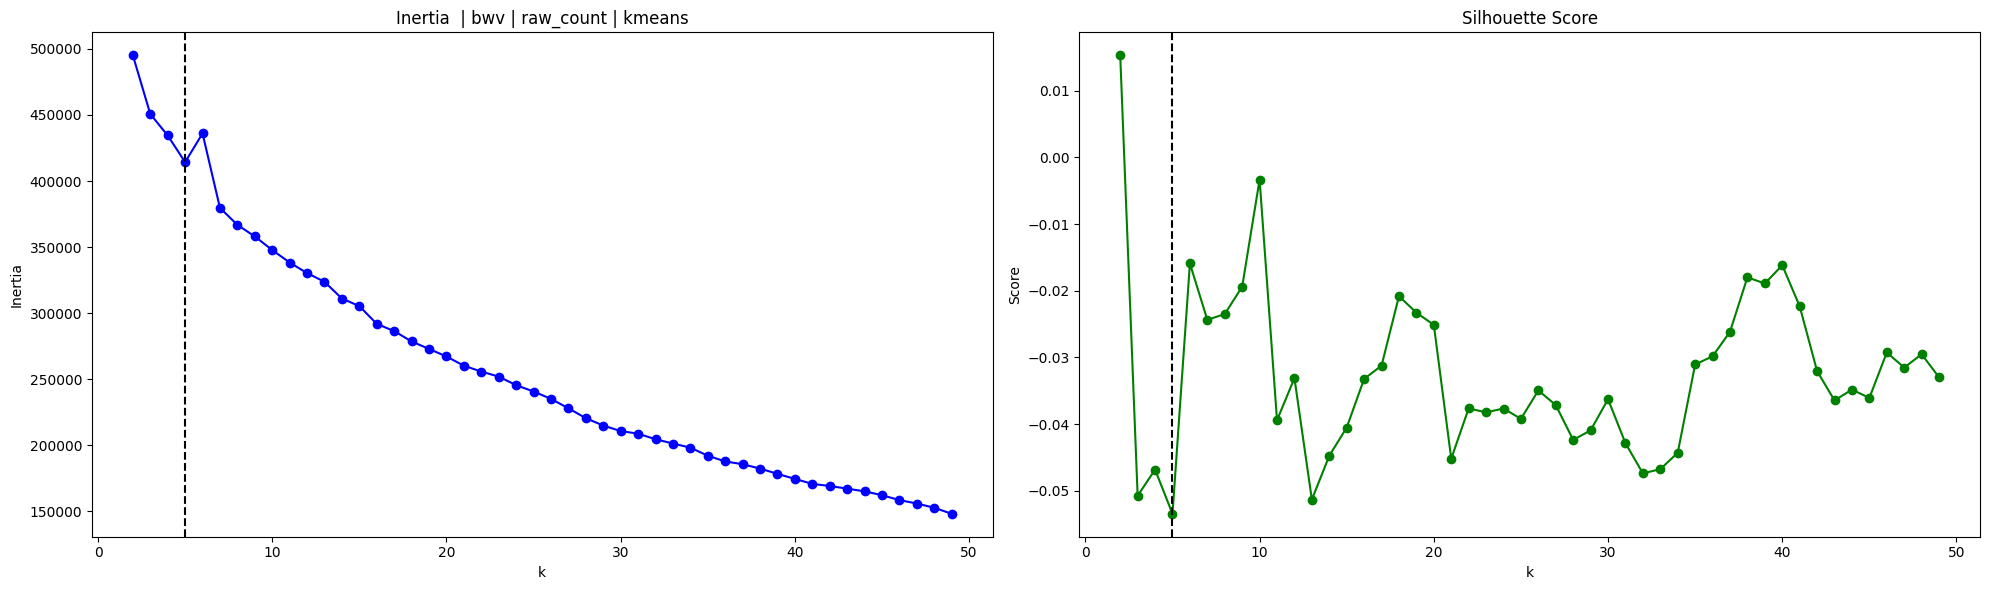

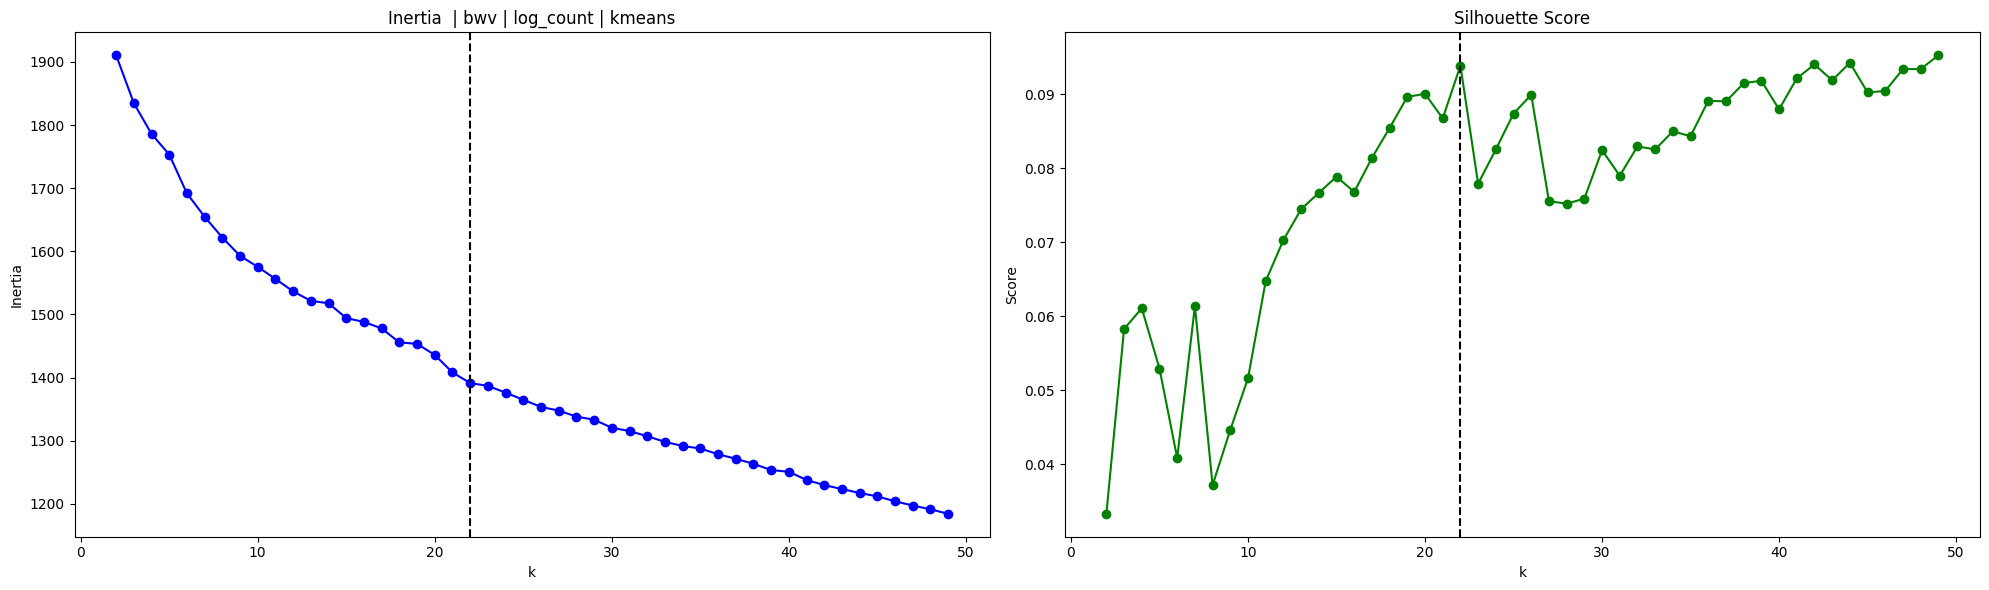

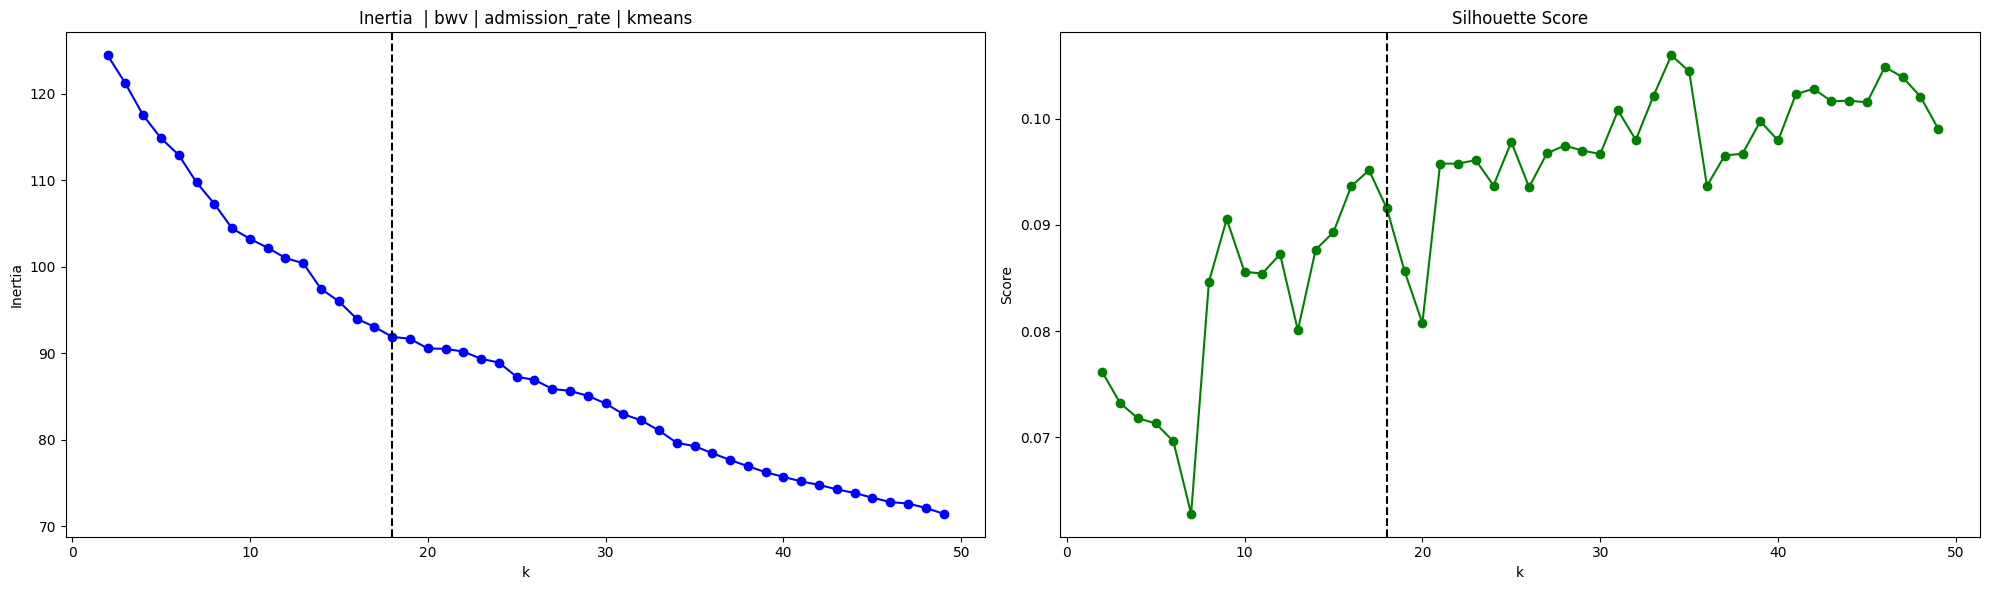

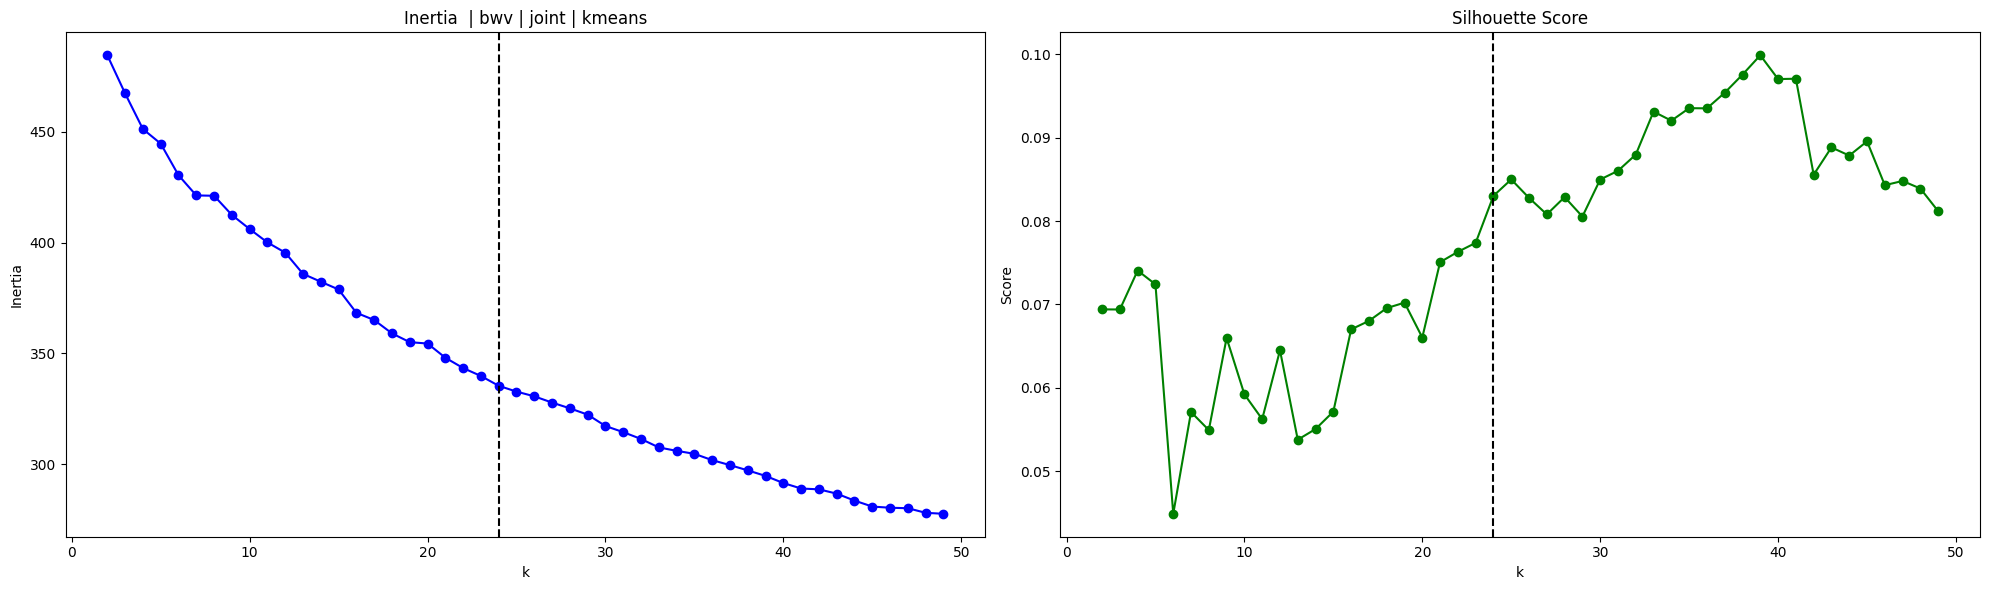

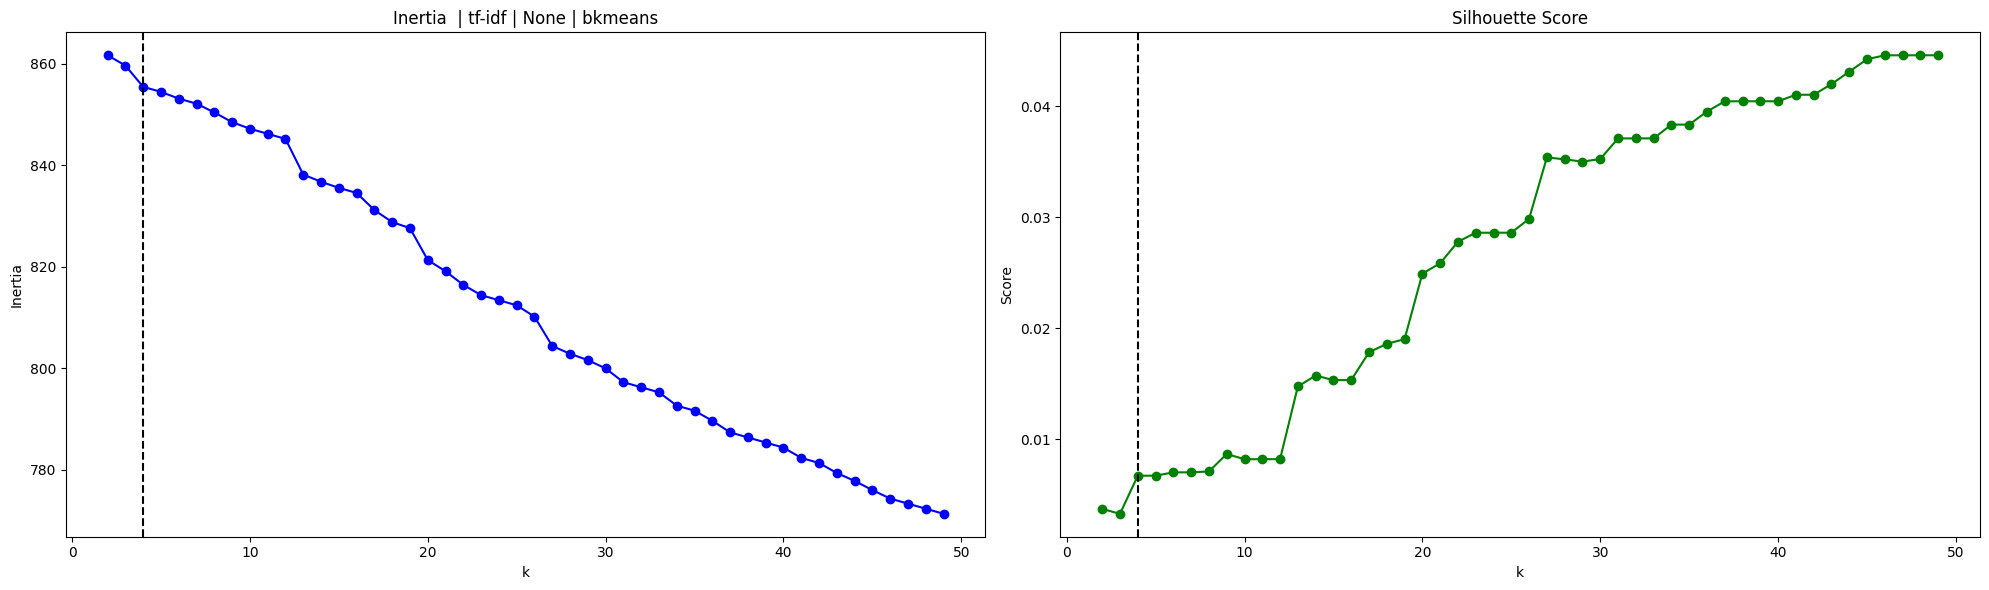

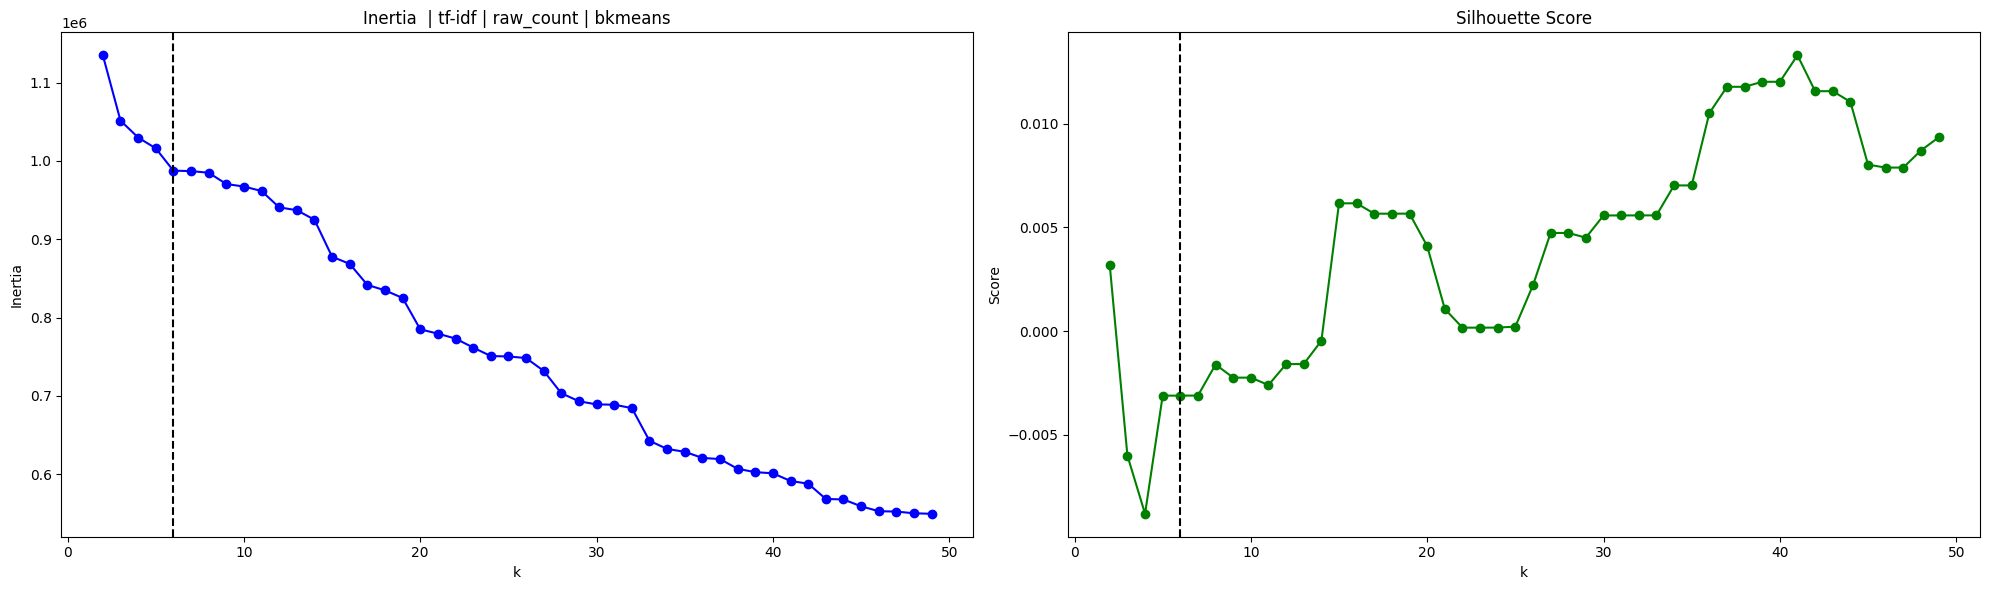

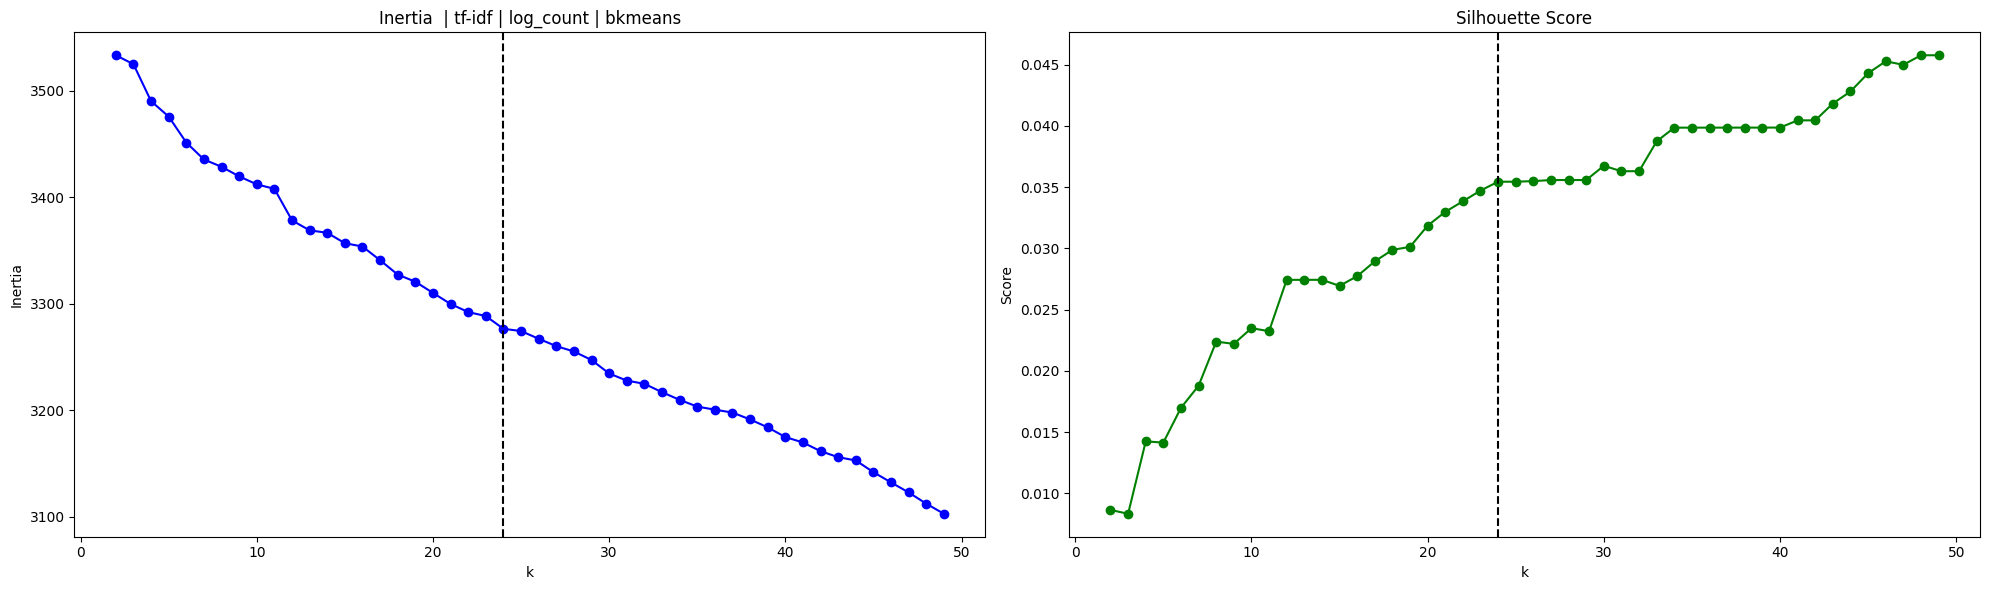

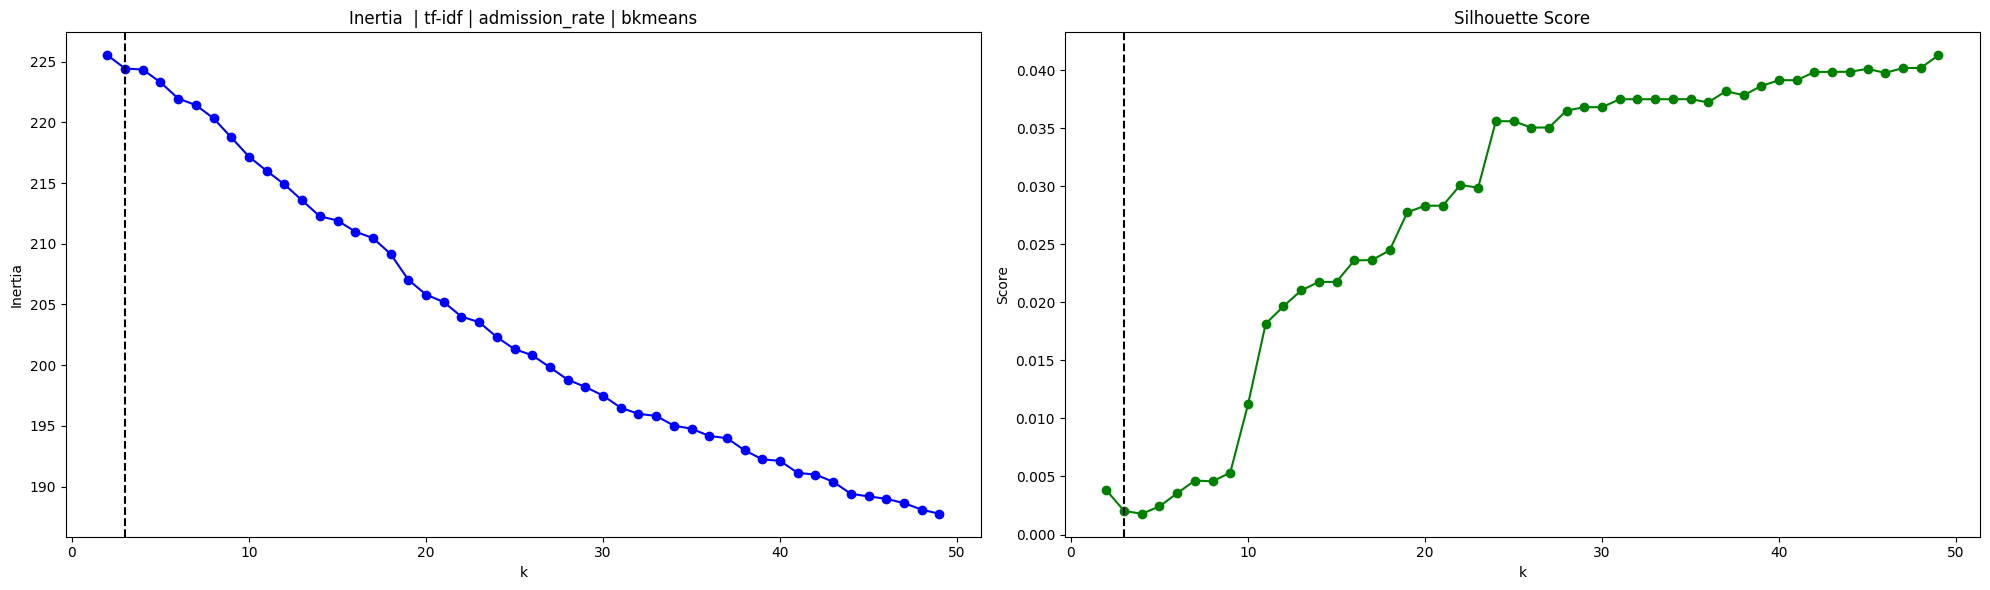

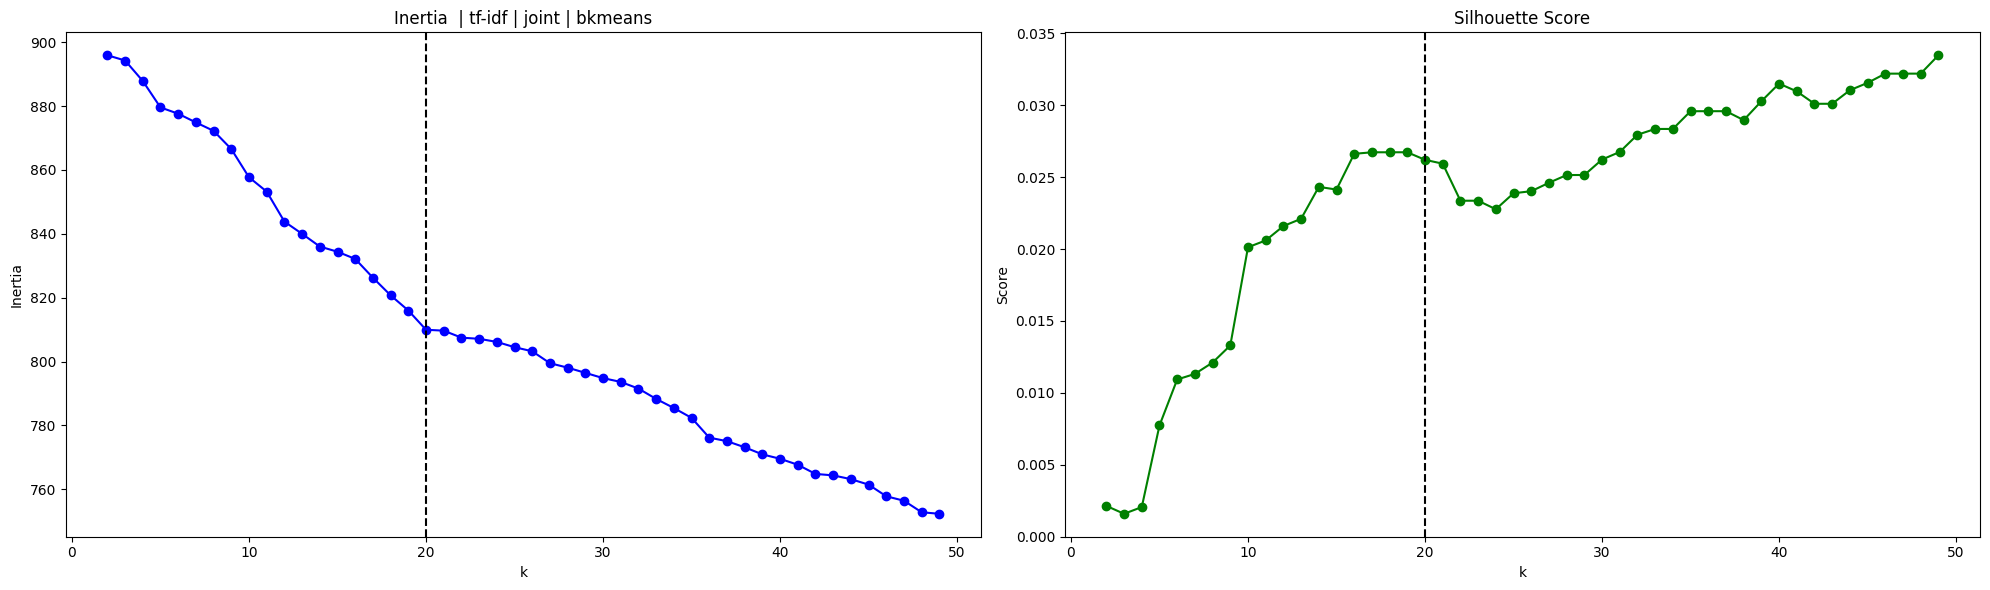

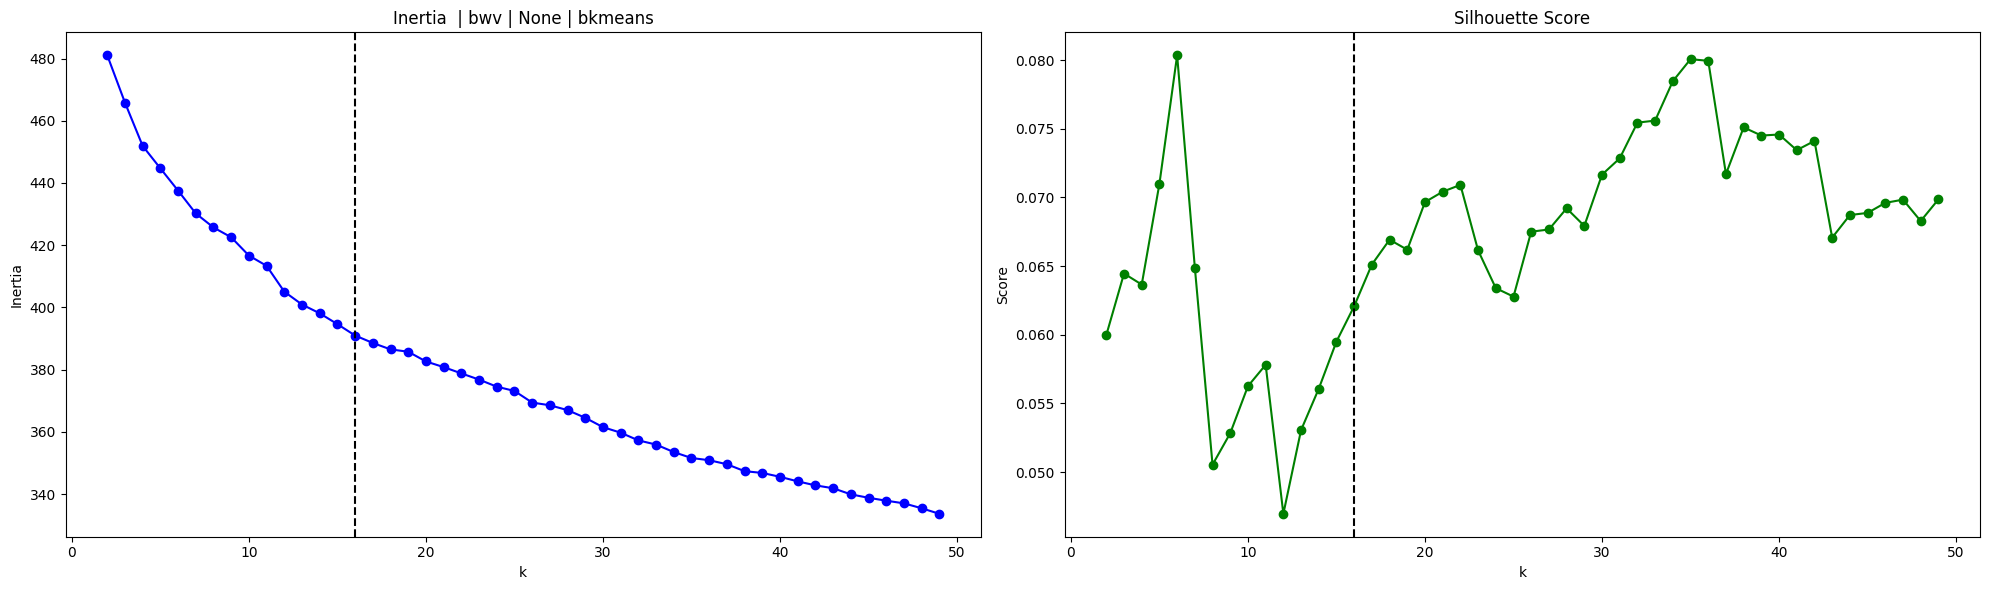

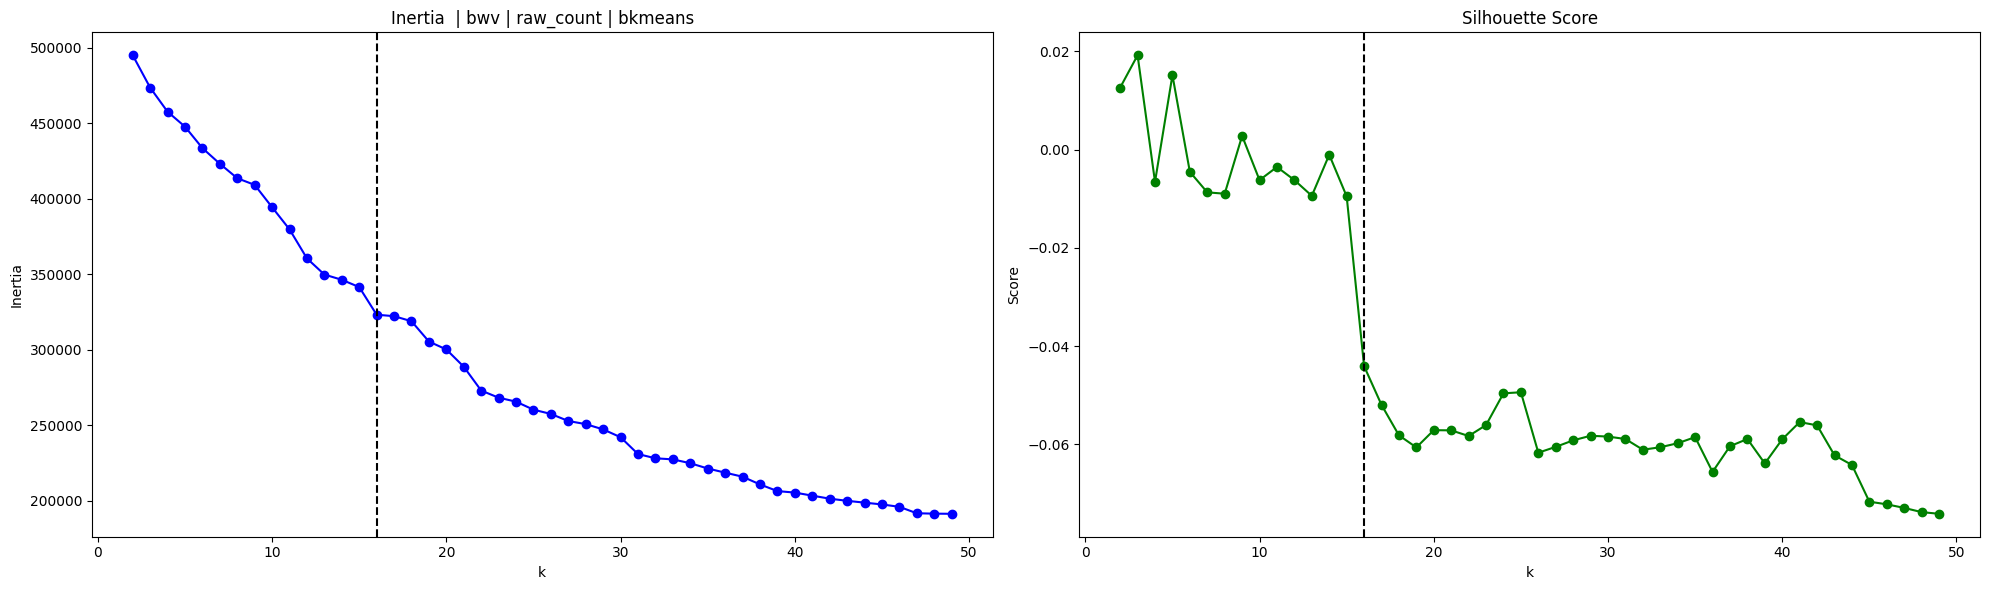

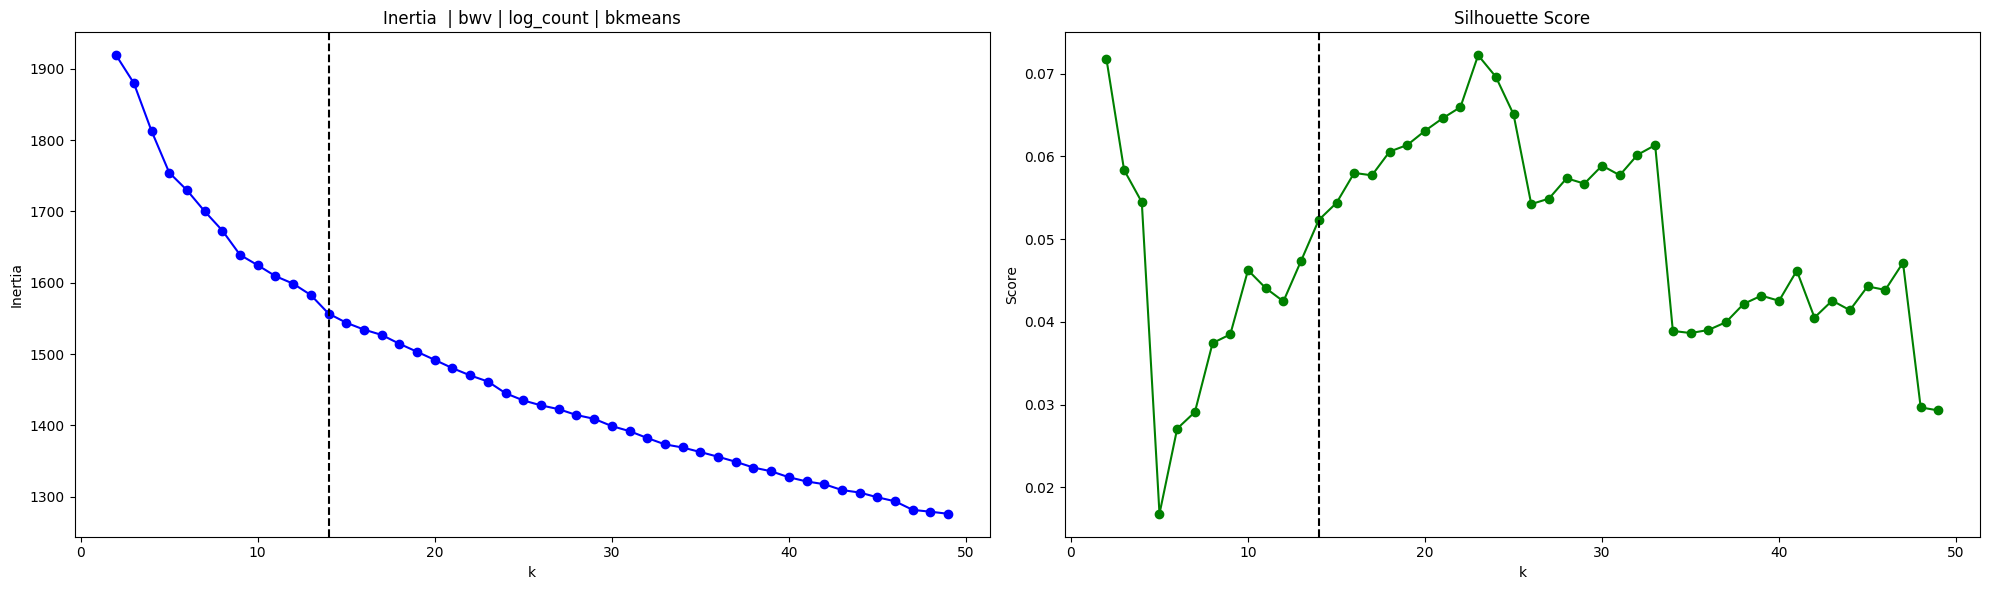

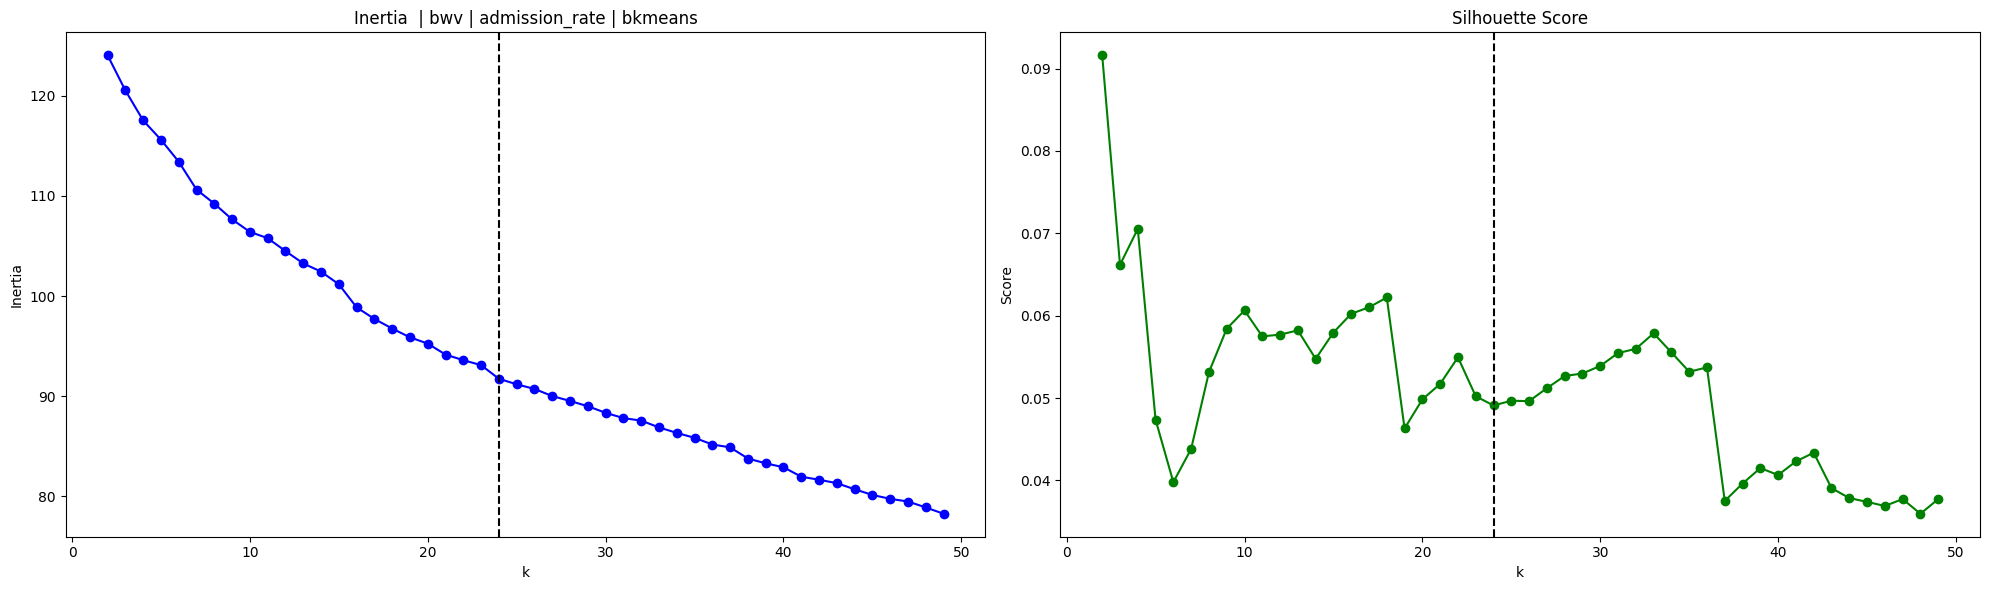

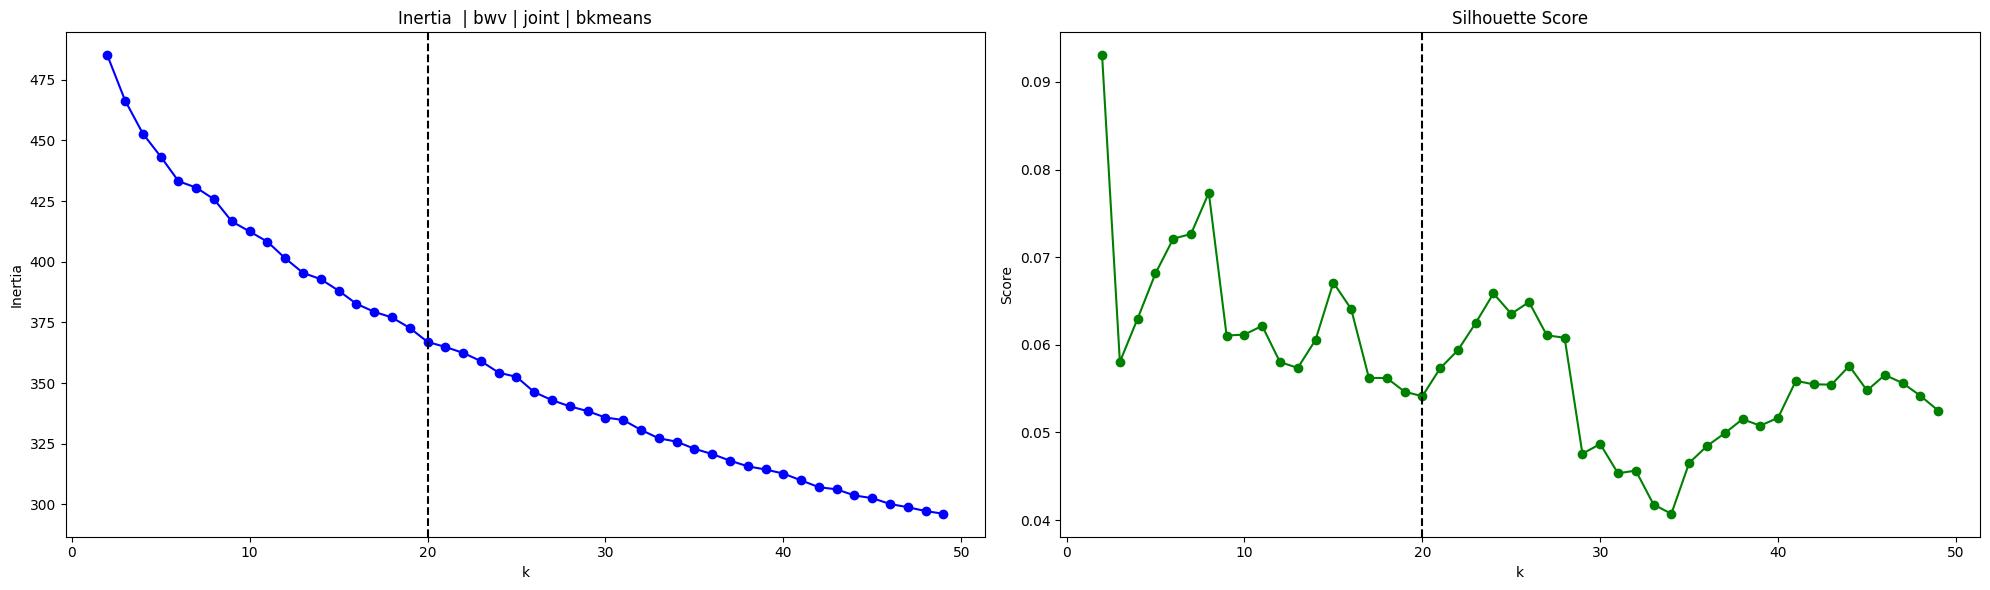

In [13]:
optimal_cluster_n = {}

for model in models:
    for i in embeddings:
        for weight_strat in weights:
        
            name = model + ' | ' + i + ' | ' + weight_strat if weight_strat else model + ' | ' + i
            optimal_cluster_n.update(
                {
                    name:find_elbow(
                        clusters_upper_bound=50,
                        data=embeddings[i],
                        reason_count=reason_count,
                        _weight_by=_weight_by,
                        weighted_by=weight_strat,
                        model_type=model,
                        vectorizer=i
                    )
                }
            )
            

### Qualitative analysis on the cluster-optimized K-means and BK- means.

In [14]:
# Models including both kmeans and bkmeans

fitted_models = {}

for i, j in enumerate(optimal_cluster_n):
    if j.split(' | ')[0] == 'kmeans':
        model_name = j
        fitted_models.update(
            {
                model_name:kmeans_model(
                    n_clusters=optimal_cluster_n[j],
                    data=embeddings[j.split(' | ')[1]],
                    weighted_by=j.split(' | ')[2] if len(j.split(' | '))==3 else None,
                    reason_count=reason_count,
                    _weight_by=_weight_by,
                    random_state=1
                )
            }
        )
    elif j.split(' | ')[0] == 'bkmeans':
        model_name = j
        fitted_models.update(
            {
                model_name:bkmeans_model(
                    n_clusters=optimal_cluster_n[j],
                    data=embeddings[j.split(' | ')[1]],
                    weighted_by=j.split(' | ')[2] if len(j.split(' | '))==3 else None,
                    reason_count=reason_count,
                    _weight_by=_weight_by,
                    random_state=1
                )
            }
        )

In [15]:
fitted_models

{'kmeans | tf-idf': KMeans(n_clusters=np.int64(7), random_state=1),
 'kmeans | tf-idf | raw_count': KMeans(n_clusters=np.int64(21), random_state=1),
 'kmeans | tf-idf | log_count': KMeans(n_clusters=np.int64(5), random_state=1),
 'kmeans | tf-idf | admission_rate': KMeans(n_clusters=np.int64(20), random_state=1),
 'kmeans | tf-idf | joint': KMeans(n_clusters=np.int64(3), random_state=1),
 'kmeans | bwv': KMeans(n_clusters=np.int64(16), random_state=1),
 'kmeans | bwv | raw_count': KMeans(n_clusters=np.int64(5), random_state=1),
 'kmeans | bwv | log_count': KMeans(n_clusters=np.int64(22), random_state=1),
 'kmeans | bwv | admission_rate': KMeans(n_clusters=np.int64(18), random_state=1),
 'kmeans | bwv | joint': KMeans(n_clusters=np.int64(24), random_state=1),
 'bkmeans | tf-idf': BisectingKMeans(n_clusters=np.int64(4), random_state=1),
 'bkmeans | tf-idf | raw_count': BisectingKMeans(n_clusters=np.int64(6), random_state=1),
 'bkmeans | tf-idf | log_count': BisectingKMeans(n_clusters=np.

In [16]:
def insert_cluster_column(
    df: pd.DataFrame,
    model_name: str,
    fitted_models: dict,
    embeddings: dict,
    unique_reasons:np.ndarray
) -> pd.DataFrame:
    unique_vals = df["REASON_VISIT_NAME"].unique() # order doesn't matter this time, so we don't need to sort()
    r = {val: _remap(val, fitted_models[model_name], embeddings[model_name.split(' | ')[1]], unique_reasons=unique_reasons) for val in unique_vals}
    df[model_name] = df["REASON_VISIT_NAME"].map(r)
    return df

In [17]:
for model_name in fitted_models:
    insert_cluster_column(
        model_name=model_name,
        df=df,
        fitted_models=fitted_models,
        embeddings=embeddings,
        unique_reasons=unique_reasons
    )

In [18]:
df

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,kmeans | tf-idf,kmeans | tf-idf | raw_count,kmeans | tf-idf | log_count,kmeans | tf-idf | admission_rate,...,bkmeans | tf-idf,bkmeans | tf-idf | raw_count,bkmeans | tf-idf | log_count,bkmeans | tf-idf | admission_rate,bkmeans | tf-idf | joint,bkmeans | bwv,bkmeans | bwv | raw_count,bkmeans | bwv | log_count,bkmeans | bwv | admission_rate,bkmeans | bwv | joint
0,A,2018-01-01,0,BREATHING PROBLEM,1,1,2,2,3,9,...,2,2,1,2,17,9,5,5,11,4
1,A,2018-01-01,0,BURN,1,0,2,6,4,9,...,2,3,15,2,7,3,0,13,17,1
2,A,2018-01-01,0,SHAKING,1,1,2,6,4,9,...,2,3,10,2,7,13,8,4,4,9
3,A,2018-01-01,0,VOMITING,1,0,2,14,4,9,...,2,3,10,2,12,14,10,10,3,17
4,A,2018-01-01,1,FROSTBITE,1,0,2,6,4,9,...,2,3,10,2,7,3,0,13,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,10,2,9,...,2,5,6,2,12,3,0,13,17,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0,3,4,1,15,...,2,3,23,2,3,15,15,8,1,2
1174307,D,2025-08-31,23,DIZZINESS,1,0,2,1,4,9,...,2,3,10,2,7,14,14,9,3,17
1174308,D,2025-08-31,23,FINGER PAIN,1,0,3,6,1,15,...,2,3,23,2,3,15,13,8,1,2


/tmp/ipykernel_59824/1798688263.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


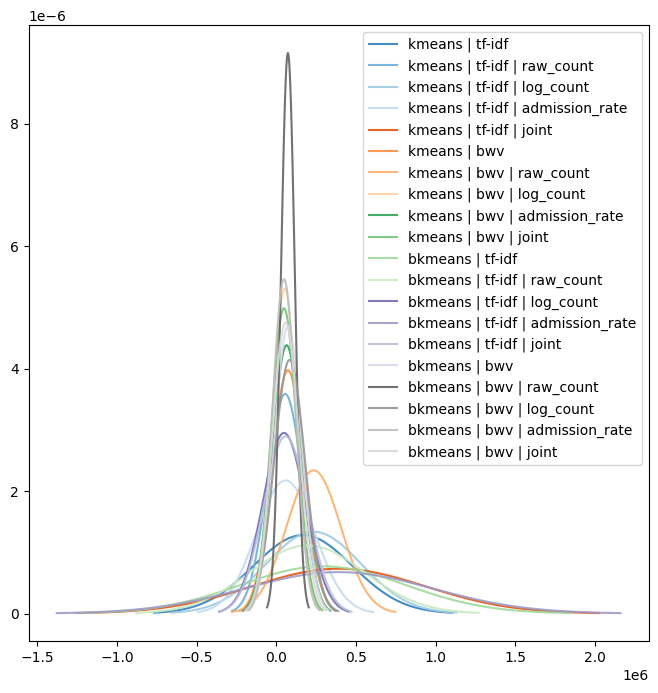

In [19]:
import matplotlib.cm as cm
plt.figure(figsize=(8,8))

cmap = cm.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, len(fitted_models))]
grouped_objs = []

for i, col in enumerate(fitted_models):
    grouped_by_model = df.groupby(by=col).size()
    grouped_objs.append(grouped_by_model)
    mu = grouped_by_model.mean()
    sigma = grouped_by_model.std()
    
    if sigma == 0:
        continue

    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
    plt.plot(x, stats.norm.pdf(x, mu, sigma), color=colors[i], label=str(col), alpha=0.9)
plt.legend()
plt.show()
    

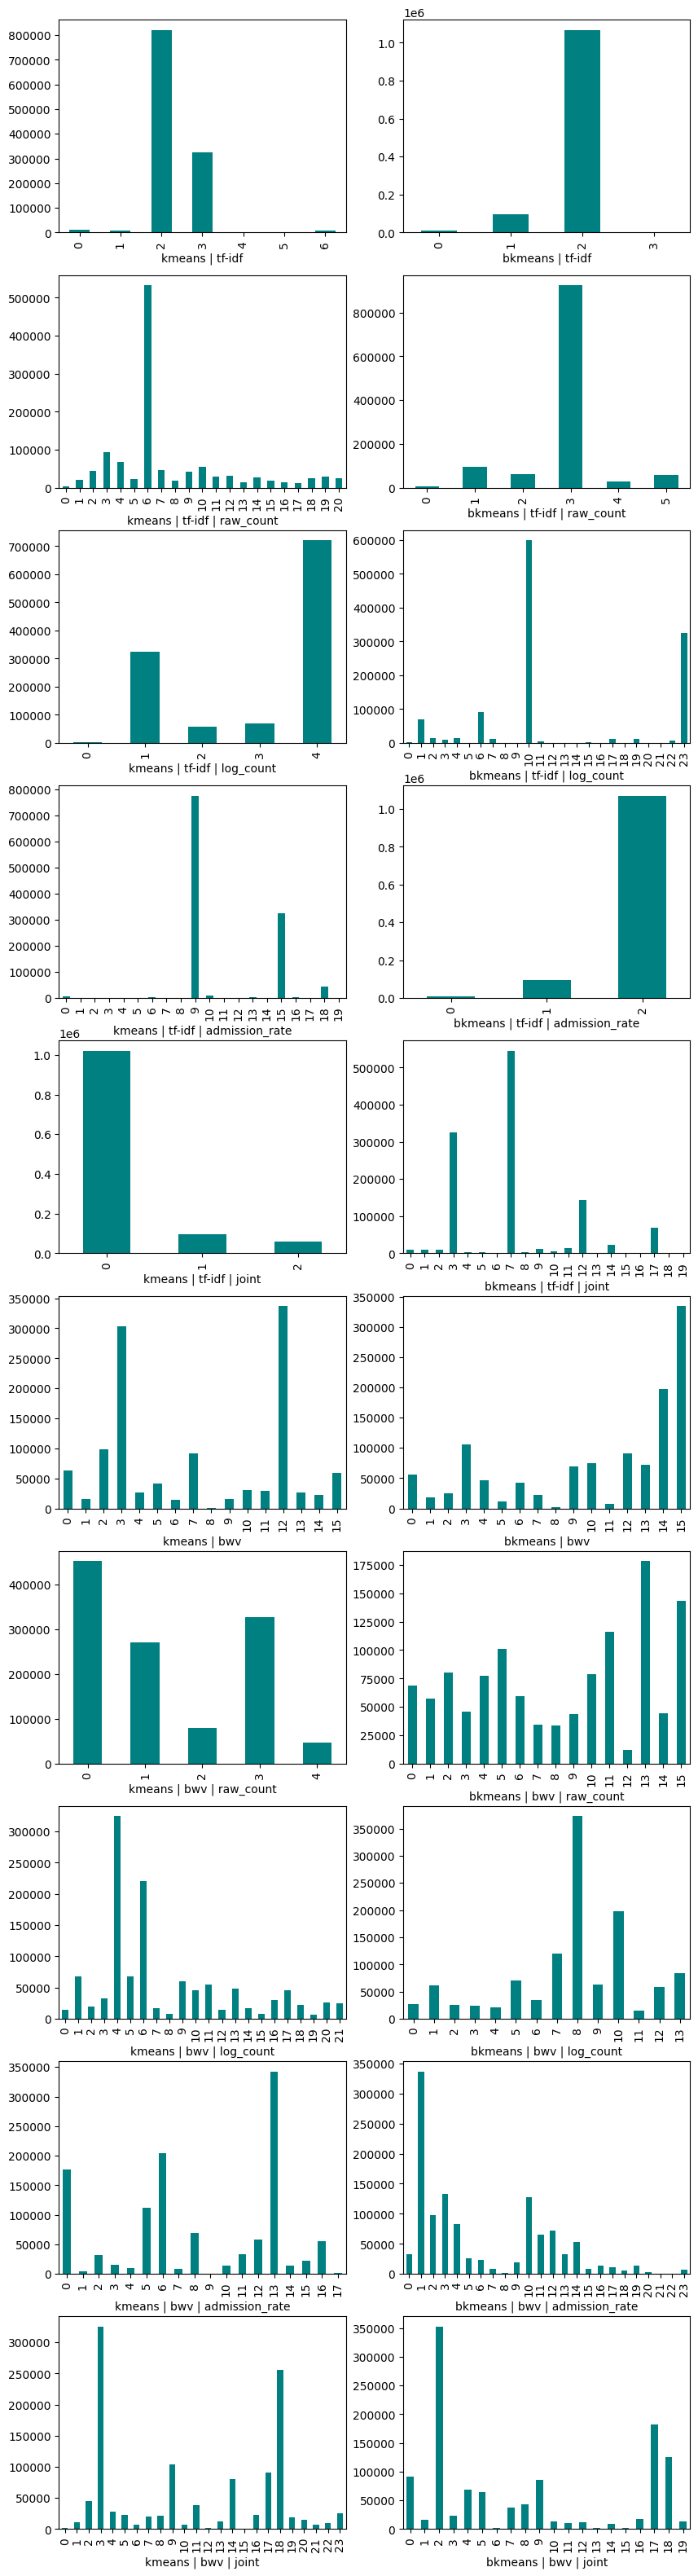

In [20]:
fig, axes = plt.subplots(10, 2, figsize=(10, 40))
for j in list(range(10)):
        grouped_objs[j].plot(kind='bar', ax=axes[j,0])
        grouped_objs[j+10].plot(kind='bar', ax=axes[j,1])

In [21]:
grouped_objs_unique = []
for i, col in enumerate(fitted_models):
    grouped_by_model = df.groupby(by=col)['REASON_VISIT_NAME'].apply(pd.unique).apply(lambda x: len(x))
    grouped_objs_unique.append(grouped_by_model)

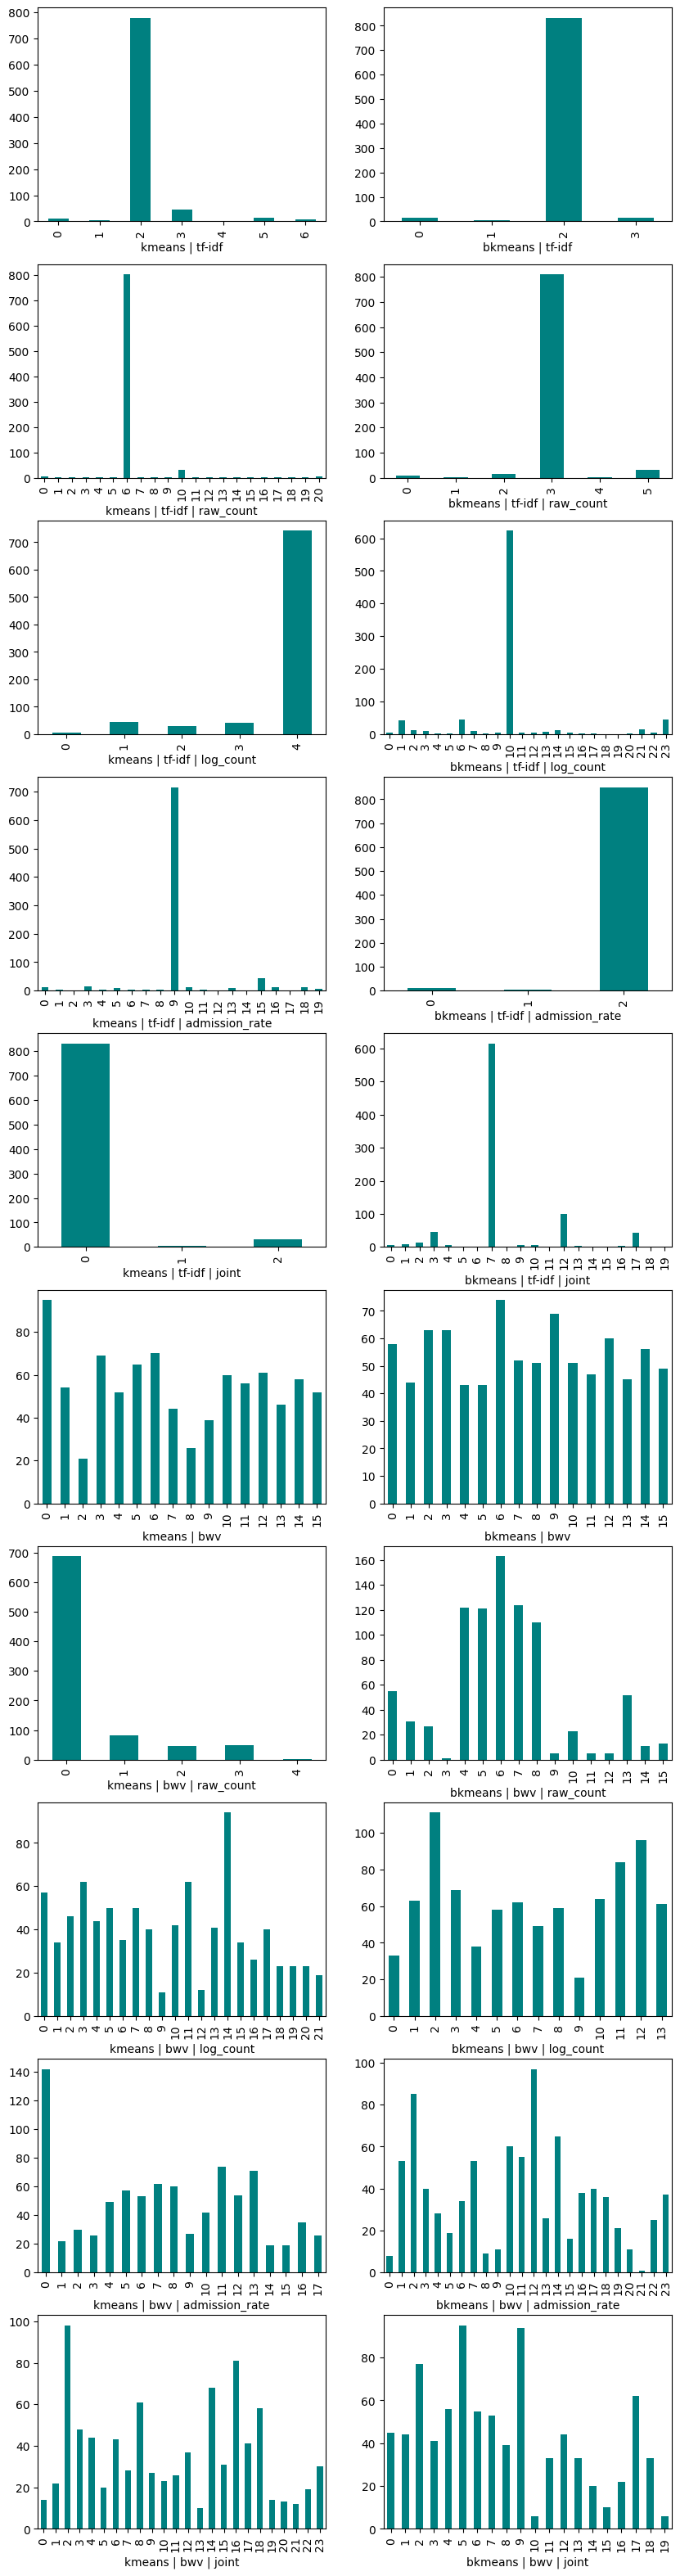

In [22]:
fig, axes = plt.subplots(10, 2, figsize=(10, 40))
for j in list(range(10)):
        grouped_objs_unique[j].plot(kind='bar', ax=axes[j,0])
        grouped_objs_unique[j+10].plot(kind='bar', ax=axes[j,1]) 

## Evaluation

### Davies Boulding scores

[Geeksforgeeks: DBI](https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/)

**Davies-Bouldin Index:** a metric for evaluating clustering quality, measuring the average similarity between clusters. The lower the better

Advantages of the Davies-Bouldin Index

*    The DBI is a relative metric, which means that it can be used to compare the clustering results of different algorithms on the same dataset.
*    The DBI has a clear interpretation: a lower DBI value indicates more compact and well-separated clusters.
*    It is a relatively simple metric to calculate.
*    It provides a global measure of the quality of a clustering solution.
*    It is relatively insensitive to the choice of distance metric.

Limitations of the Davies-Bouldin Index

*    The Davies-Bouldin Index is sensitive to outliers and noise in the data.
*    The Davies-Bouldin Index does not take into account the structure or distribution of data, such as clusters within clusters or non-linear relationships.
*    The Davies-Bouldin Index only considers the pairwise distances between cluster centroids and cluster members.
*    The DBI can be computationally expensive to calculate for large datasets.
*    The DBI is not suitable for all clustering tasks. For example, it is not well-suited for clustering tasks where the clusters are not well-separated.

In [23]:
fitted_models, embeddings.keys()

({'kmeans | tf-idf': KMeans(n_clusters=np.int64(7), random_state=1),
  'kmeans | tf-idf | raw_count': KMeans(n_clusters=np.int64(21), random_state=1),
  'kmeans | tf-idf | log_count': KMeans(n_clusters=np.int64(5), random_state=1),
  'kmeans | tf-idf | admission_rate': KMeans(n_clusters=np.int64(20), random_state=1),
  'kmeans | tf-idf | joint': KMeans(n_clusters=np.int64(3), random_state=1),
  'kmeans | bwv': KMeans(n_clusters=np.int64(16), random_state=1),
  'kmeans | bwv | raw_count': KMeans(n_clusters=np.int64(5), random_state=1),
  'kmeans | bwv | log_count': KMeans(n_clusters=np.int64(22), random_state=1),
  'kmeans | bwv | admission_rate': KMeans(n_clusters=np.int64(18), random_state=1),
  'kmeans | bwv | joint': KMeans(n_clusters=np.int64(24), random_state=1),
  'bkmeans | tf-idf': BisectingKMeans(n_clusters=np.int64(4), random_state=1),
  'bkmeans | tf-idf | raw_count': BisectingKMeans(n_clusters=np.int64(6), random_state=1),
  'bkmeans | tf-idf | log_count': BisectingKMeans(n

In [24]:
dbis = {}

for fm in fitted_models:
    dbis[fm] = {
        'model': fitted_models[fm],
        'dbi': davies_bouldin_score(
            embeddings[fm.split(' | ')[1]],
            fitted_models[fm].labels_
        )
    }


dbis['kmeans | tf-idf']

{'model': KMeans(n_clusters=np.int64(7), random_state=1),
 'dbi': 3.498522977167646}

In [25]:
# %matplotlib widget
# import matplotlib.pyplot as plt


# pca = PCA(n_components=3)
# X_reduced = pca.fit_transform(e_w)

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')Ficedfnnn x x

# scatter = ax.scatter(
#     X_reduced[:, 0],
#     X_reduced[:, 1],
#     X_reduced[:, 2],
#     c=m4.labels_,
#     cmap='Paired',
#     s=10,
#     alpha=1
# )

# ax.set_title("3D Text Clustering Visualization")
# ax.set_xlabel("Principal Component 1")
# ax.set_ylabel("Principal Component 2")
# ax.set_zlabel("Principal Component 3")

# # --- cluster centers ---
# centers = m4.cluster_centers_
# centers_reduced = pca.transform(centers)

# ax.scatter(
#     centers_reduced[:, 0],
#     centers_reduced[:, 1],
#     centers_reduced[:, 2],
#     c=np.unique(m4.labels_),
#     cmap='Paired',
#     s=200,
#     marker='X',
#     alpha=1,
#     label='Cluster Centers'
# )

# ax.legend()
# fig.colorbar(scatter, ax=ax, label='Cluster Label')
# ax.view_init(elev=30, azim=120)

# plt.show()

In [26]:
%matplotlib inline

In [29]:
df.to_csv('insterted_clusters.csv')